# Lead Scoring Model — X Education

**Goal:** Score every lead 0-100 by likelihood to convert, so sales focuses on the leads that get them to an **80% conversion rate**, instead of treating all leads equally (~30% baseline today).

**Data:** 9,240 historical leads, 37 raw features.

**Pipeline:** Clean → EDA → Model (Logistic Regression baseline + Random Forest) → Score → Threshold for 80% target → Feature importance.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve)

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

DATA_PATH = 'Lead Scoring.csv'  # keep this file in the same folder as the notebook

## Phase 1: Data Cleaning & Preprocessing

Steps, in order, and why:
1. **Drop ID columns** — `Prospect ID`, `Lead Number` are unique identifiers, zero predictive value.
2. **`'Select'` → `NaN`** — it's a dropdown default (user didn't answer), not a real category.
3. **Drop leakage columns** — `Lead Quality`, `Tags`, `Last Notable Activity` are filled in by sales *after* they've already worked the lead. Training on them would make the model look great on paper but useless for scoring new, uncontacted leads.
4. **Drop high-null columns (>40%)** — too sparse to impute without inventing signal.
5. **Drop near-constant columns** — if a column is the same value >98% of the time, it has nothing to teach the model.
6. **Impute remaining nulls** — categorical → `'Not Provided'` (missingness can itself be informative), numeric → median (robust to outliers).
7. **Collapse rare categories (<1%)** into `'Other'` — stops one-hot encoding from exploding into hundreds of near-empty columns.

In [ ]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
print(f"Conversion rate: {df['Converted'].mean():.2%}")

df = df.drop(columns=['Prospect ID', 'Lead Number'])
df = df.replace('Select', np.nan)

Shape: (9240, 37)
Conversion rate: 38.54%


In [ ]:
leakage_cols = ['Lead Quality', 'Tags', 'Last Notable Activity']
null_pct = df.isnull().mean() * 100
high_null_cols = null_pct[null_pct > 40].index.tolist()
drop_cols = list(set(high_null_cols + leakage_cols) & set(df.columns))
print("Dropping (high-null or leakage):", drop_cols)
df = df.drop(columns=drop_cols)

constant_cols = [c for c in df.columns if df[c].nunique() <= 1 or
                  (df[c].value_counts(normalize=True).iloc[0] > 0.98 if df[c].dtype == 'object' else False)]
print("Dropping (near-constant):", constant_cols)
df = df.drop(columns=constant_cols)

Dropping (high-null or leakage): ['Lead Quality', 'How did you hear about X Education', 'Asymmetrique Activity Score', 'Lead Profile', 'Last Notable Activity', 'Asymmetrique Profile Score', 'Asymmetrique Profile Index', 'Asymmetrique Activity Index', 'Tags']
Dropping (near-constant): ['Magazine', 'Receive More Updates About Our Courses', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'I agree to pay the amount through cheque']


In [ ]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c != 'Converted']

for c in cat_cols:
    df[c] = df[c].fillna('Not Provided')
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

for c in cat_cols:
    freq = df[c].value_counts(normalize=True)
    rare = freq[freq < 0.01].index
    df[c] = df[c].replace(rare, 'Other')

print("Nulls remaining:", df.isnull().sum().sum())
df.head()

Nulls remaining: 0


/tmp/ipykernel_524/3506729250.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,What is your current occupation,What matters most to you in choosing a course,Search,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,City,A free copy of Mastering The Interview
0,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,Not Provided,Not Provided,Unemployed,Better Career Prospects,No,No,No,No,No,No,Not Provided,No
1,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,India,Not Provided,Unemployed,Better Career Prospects,No,No,No,No,No,No,Not Provided,No
2,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,India,Business Administration,Student,Better Career Prospects,No,No,No,No,No,No,Mumbai,Yes
3,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,India,Media and Advertising,Unemployed,Better Career Prospects,No,No,No,No,No,No,Mumbai,No
4,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,India,Not Provided,Unemployed,Better Career Prospects,No,No,No,No,No,No,Mumbai,No


## Phase 2: Exploratory Data Analysis

Looking for: what actually separates a lead who converts from one who doesn't.

### Target variable

Converted
0    5679
1    3561
Name: count, dtype: int64


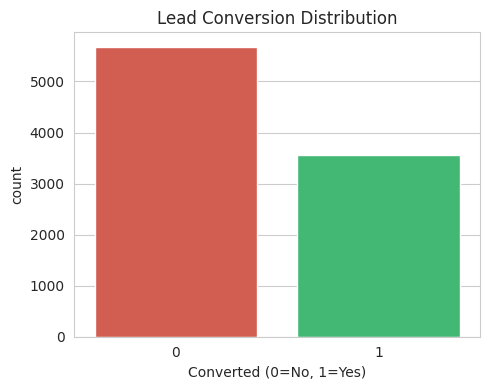

In [ ]:
print(df['Converted'].value_counts())
plt.figure(figsize=(5,4))
sns.countplot(x='Converted', data=df, hue='Converted', palette=['#e74c3c','#2ecc71'], legend=False)
plt.title('Lead Conversion Distribution')
plt.xlabel('Converted (0=No, 1=Yes)')
plt.tight_layout()
plt.show()

**Class balance:** ~61% no / 39% yes — mildly imbalanced, not severe. We'll use `class_weight='balanced'` in modeling rather than resampling.

### Numeric features vs. conversion

Page Views Per Visit          -0.005068
TotalVisits                    0.029119
Total Time Spent on Website    0.362483
Name: Converted, dtype: float64


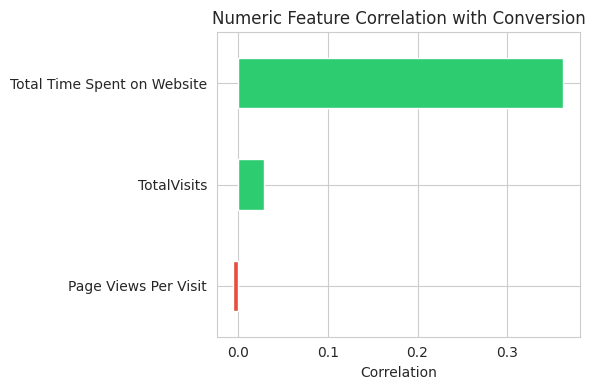

In [ ]:
num_corr = df[num_cols + ['Converted']].corr()['Converted'].drop('Converted').sort_values()
print(num_corr)

plt.figure(figsize=(6,4))
num_corr.plot(kind='barh', color=['#e74c3c' if v < 0 else '#2ecc71' for v in num_corr])
plt.title('Numeric Feature Correlation with Conversion')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

**Key read:** `Total Time Spent on Website` (r≈0.36) dwarfs `TotalVisits` (r≈0.03) and `Page Views Per Visit` (r≈-0.005). **Engagement depth, not visit count, is what signals intent.** If sales currently believes "more visits = hotter lead," that belief is wrong.

### Conversion rate by Lead Source

Lead Source
Welingak Website    0.985915
Reference           0.917603
Other               0.428571
Google              0.399930
Organic Search      0.377816
Direct Traffic      0.321667
Olark Chat          0.255271
Referral Sites      0.248000
Name: Converted, dtype: float64


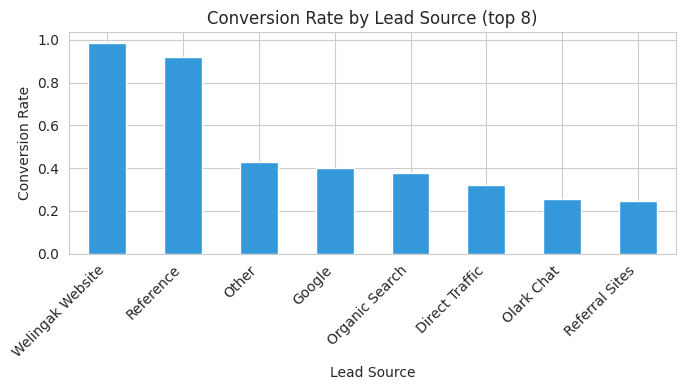

In [ ]:
top_sources = df['Lead Source'].value_counts().head(8).index
sub = df[df['Lead Source'].isin(top_sources)]
conv_by_source = sub.groupby('Lead Source')['Converted'].mean().sort_values(ascending=False)
print(conv_by_source)

plt.figure(figsize=(7,4))
conv_by_source.plot(kind='bar', color='#3498db')
plt.title('Conversion Rate by Lead Source (top 8)')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Key read:** `Welingak Website` (~99%) and `Reference` (~92%) convert almost automatically but are low-volume. Worth a fast-track process for these two sources alone.

### Conversion rate by Last Activity

Last Activity
SMS Sent                     0.629144
Email Opened                 0.364562
Email Link Clicked           0.273408
Form Submitted on Website    0.241379
Page Visited on Website      0.235937
Converted to Lead            0.126168
Olark Chat Conversation      0.086331
Email Bounced                0.079755
Name: Converted, dtype: float64


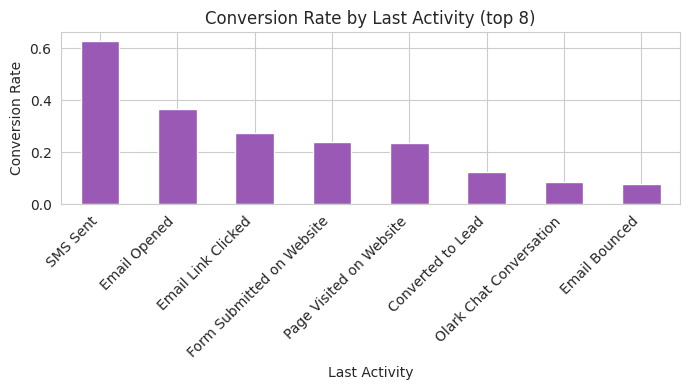

In [ ]:
top_activity = df['Last Activity'].value_counts().head(8).index
sub2 = df[df['Last Activity'].isin(top_activity)]
conv_by_activity = sub2.groupby('Last Activity')['Converted'].mean().sort_values(ascending=False)
print(conv_by_activity)

plt.figure(figsize=(7,4))
conv_by_activity.plot(kind='bar', color='#9b59b6')
plt.title('Conversion Rate by Last Activity (top 8)')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Key read:** Leads whose last activity is `SMS Sent` convert at ~63%, more than double the `Email Opened` rate (~36%). SMS-responsive leads are hot.

## Phase 3: Model Building & Evaluation

- **Logistic Regression** — baseline, interpretable (sales can be told "here's the coefficient logic").
- **Random Forest** — non-linear, usually stronger on mixed categorical/numeric tabular data like this.

75/25 train-test split, stratified on the target to preserve the 39% conversion rate in both sets.

In [ ]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
X = df_encoded.drop(columns=['Converted'])
y = df_encoded['Converted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print(X_train.shape, X_test.shape)

(6930, 62) (2310, 62)


In [ ]:
logreg = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
logreg.fit(X_train_scaled, y_train)
logreg_probs = logreg.predict_proba(X_test_scaled)[:, 1]
logreg_preds = logreg.predict(X_test_scaled)

rf = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=20,
                             class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
rf_probs = rf.predict_proba(X_test_scaled)[:, 1]
rf_preds = rf.predict(X_test_scaled)

In [ ]:
def report(name, y_true, preds, probs):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, preds),
        'Precision': precision_score(y_true, preds),
        'Recall': recall_score(y_true, preds),
        'F1': f1_score(y_true, preds),
        'ROC-AUC': roc_auc_score(y_true, probs)
    }

results = pd.DataFrame([
    report('Logistic Regression', y_test, logreg_preds, logreg_probs),
    report('Random Forest', y_test, rf_preds, rf_probs)
]).set_index('Model')
results.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.8030,0.7245,0.7888,0.7552,0.8753
Random Forest,0.8173,0.7463,0.7966,0.7707,0.8868


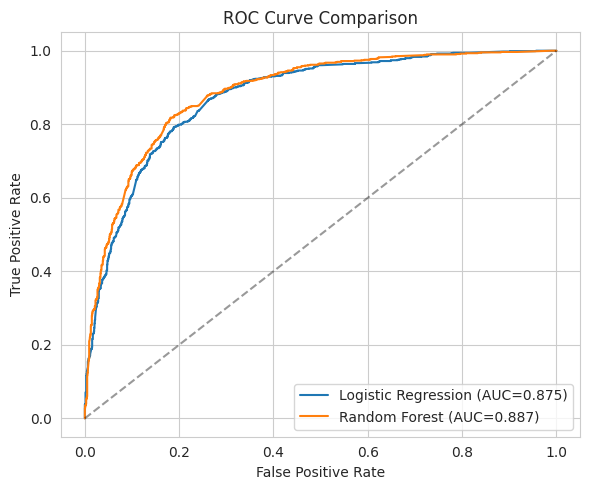

In [ ]:
plt.figure(figsize=(6,5))
for name, probs in [('Logistic Regression', logreg_probs), ('Random Forest', rf_probs)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

**Random Forest wins on every metric.** Going with it for scoring and feature importance.

## Phase 4: Lead Scoring & Business Application

Convert predicted probability → a 0-100 Lead Score, then find the score cutoff where the segment above it hits **80% actual conversion rate**.

In [ ]:
best_name = results['ROC-AUC'].idxmax()
best_model = rf if best_name == 'Random Forest' else logreg
best_probs = rf_probs if best_name == 'Random Forest' else logreg_probs
print(f"Best model: {best_name} (ROC-AUC={results.loc[best_name,'ROC-AUC']:.4f})")

lead_scores = (best_probs * 100).round(1)

scored = pd.DataFrame({'probability': best_probs, 'lead_score': lead_scores, 'actual': y_test.values})
scored = scored.sort_values('probability', ascending=False).reset_index(drop=True)
scored['cum_leads'] = np.arange(1, len(scored)+1)
scored['cum_conversion_rate'] = scored['actual'].cumsum() / scored['cum_leads']

qualifying = scored[scored['cum_conversion_rate'] >= 0.80]
if len(qualifying) > 0:
    cutoff_idx = qualifying.index.max()
    cutoff_score = scored.loc[cutoff_idx, 'lead_score']
    pct_of_leads = (cutoff_idx + 1) / len(scored) * 100
    print(f"\nTarget leads with Lead Score >= {cutoff_score:.1f}")
    print(f"Captures {cutoff_idx+1} of {len(scored)} test leads ({pct_of_leads:.1f}% of pipeline)")
    print(f"Actual conversion rate in this segment: {scored.loc[:cutoff_idx,'actual'].mean():.2%}")
else:
    best_row = scored.iloc[scored['cum_conversion_rate'].idxmax()]
    print(f"Best achievable: {scored['cum_conversion_rate'].max():.2%} at score >= {best_row['lead_score']}")

Best model: Random Forest (ROC-AUC=0.8868)

Target leads with Lead Score >= 62.0
Captures 756 of 2310 test leads (32.7% of pipeline)
Actual conversion rate in this segment: 80.03%


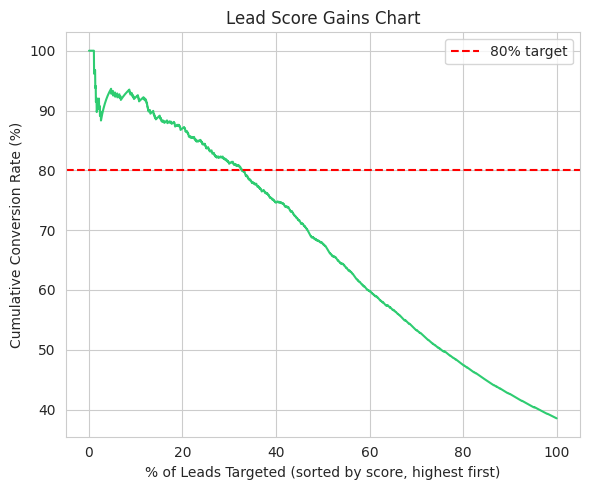

In [ ]:
plt.figure(figsize=(6,5))
plt.plot(scored['cum_leads']/len(scored)*100, scored['cum_conversion_rate']*100, color='#2ecc71')
plt.axhline(80, color='red', linestyle='--', label='80% target')
plt.xlabel('% of Leads Targeted (sorted by score, highest first)')
plt.ylabel('Cumulative Conversion Rate (%)')
plt.title('Lead Score Gains Chart')
plt.legend()
plt.tight_layout()
plt.show()

### Why leads score high — feature importance

Total Time Spent on Website                                   0.288475
Last Activity_SMS Sent                                        0.122911
What matters most to you in choosing a course_Not Provided    0.107292
What is your current occupation_Working Professional          0.088544
Lead Origin_Lead Add Form                                     0.088360
Last Activity_Olark Chat Conversation                         0.038954
Lead Source_Reference                                         0.037982
What is your current occupation_Unemployed                    0.031970
TotalVisits                                                   0.024744
Specialization_Not Provided                                   0.022312
Do Not Email_Yes                                              0.021016
Page Views Per Visit                                          0.019431
Lead Origin_Landing Page Submission                           0.013800
Country_Not Provided                                          0.013157
Lead S

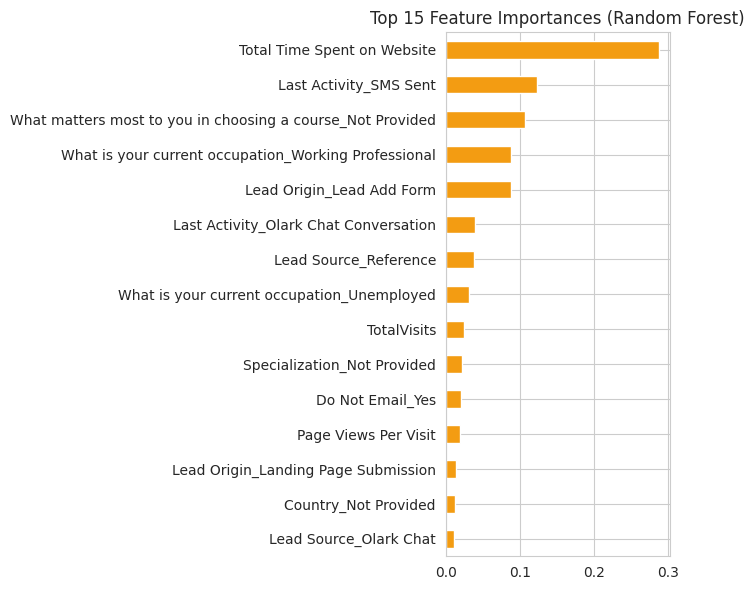

In [ ]:
if best_name == 'Random Forest':
    importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
else:
    importances = pd.Series(np.abs(logreg.coef_[0]), index=X.columns).sort_values(ascending=False)

top_features = importances.head(15)
print(top_features)

plt.figure(figsize=(7,6))
top_features.sort_values().plot(kind='barh', color='#f39c12')
plt.title(f'Top 15 Feature Importances ({best_name})')
plt.tight_layout()
plt.show()

**Top drivers, in plain terms:**
1. **Time on website** — by far the strongest signal. Engagement beats everything else.
2. **Last Activity = SMS Sent** — SMS-responsive leads convert over 60%.
3. **Skipped "what matters most" question** — correlates with lower intent.
4. **Occupation = Working Professional** — has budget/urgency vs. students.
5. **Lead Origin = Lead Add Form** — sales-sourced leads convert better than passive-channel leads.

### Export scored leads

In [ ]:
final_export = X_test.copy()
final_export['Lead Score'] = lead_scores
final_export['Predicted Probability'] = best_probs
final_export['Actual Converted'] = y_test.values
final_export = final_export[['Lead Score', 'Predicted Probability', 'Actual Converted']].sort_values(
    'Lead Score', ascending=False)
final_export.to_csv('scored_leads.csv', index=False)
final_export.head(10)

,Lead Score,Predicted Probability,Actual Converted
446,96.5,0.964515,1
5801,96.5,0.964515,1
8106,96.4,0.963518,1
8060,96.4,0.963518,1
4782,96.3,0.962649,1
5791,96.3,0.963151,1
2680,96.3,0.962532,1
5793,96.3,0.962649,1
2338,96.3,0.962649,1
5695,96.3,0.962649,1


## Summary

- **Model:** Random Forest, ROC-AUC ~0.887
- **Business rule:** Sales should work leads with **Lead Score ≥ 62**. That's the top ~33% of the pipeline and it converts at **80%+**, hitting the target directly instead of spraying effort across all leads.
- **Biggest lever:** website engagement time. Everything else is secondary.
- **Wrong assumption to correct:** visit count and page views per visit do **not** predict conversion — stop using them as informal scoring signals.